In [2]:
import numpy as np

file_paths = {
    "Train": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_train.npz",
    "Validation": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val.npz",
    "Validation Balanced": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val_balanced.npz"
}

def inspect_npz_files(paths):
    for name, path in paths.items():
        print(f"### Inspecting: {name} ###")
        try:
            with np.load(path) as data:
                # 1. List all keys (usually 'x' for data, 'y' for labels)
                keys = data.files
                print(f"Internal Keys: {keys}")
                
                for key in keys:
                    arr = data[key]
                    # 2. Get Shape, Type, and Range
                    print(f"  -> Key '{key}':")
                    print(f"     Shape: {arr.shape}")
                    print(f"     Dtype: {arr.dtype}")
                    
                    # If it's numerical data, show min/max/mean for sanity check
                    if np.issubdtype(arr.dtype, np.number):
                        print(f"     Range: [{arr.min():.2f}, {arr.max():.2f}]")
                        print(f"     Mean:  {arr.mean():.4f}")
            print("-" * 40)
            
        except FileNotFoundError:
            print(f"Error: File not found at {path}")
        except Exception as e:
            print(f"An error occurred: {e}")

inspect_npz_files(file_paths)

### Inspecting: Train ###
Internal Keys: ['train_signals', 'train_labels']
  -> Key 'train_signals':
     Shape: (37666, 23, 256)
     Dtype: float64
     Range: [-2738.36, 2932.94]
     Mean:  0.2442
  -> Key 'train_labels':
     Shape: (37666,)
     Dtype: int64
     Range: [0.00, 1.00]
     Mean:  0.2144
----------------------------------------
### Inspecting: Validation ###
Internal Keys: ['val_signals', 'val_labels']
  -> Key 'val_signals':
     Shape: (8071, 23, 256)
     Dtype: float64
     Range: [-2471.50, 2429.01]
     Mean:  0.1474
  -> Key 'val_labels':
     Shape: (8071,)
     Dtype: int64
     Range: [0.00, 1.00]
     Mean:  0.2197
----------------------------------------
### Inspecting: Validation Balanced ###
Internal Keys: ['val_signals', 'val_labels']
  -> Key 'val_signals':
     Shape: (3546, 23, 256)
     Dtype: float64
     Range: [-2328.11, 2429.01]
     Mean:  0.1559
  -> Key 'val_labels':
     Shape: (3546,)
     Dtype: int64
     Range: [0.00, 1.00]
     Mean: 

In [1]:
import numpy as np
from collections import Counter

# Define the file paths
file_paths = {
    "Train": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_train.npz",
    "Validation": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val.npz",
    "Validation Balanced": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val_balanced.npz"
}

def analyze_class_distribution(paths):
    print(f"{'Dataset':<20} | {'Class Counts (Label: Count)':<30}")
    print("-" * 55)
    
    for name, path in paths.items():
        try:
            # Load the npz file
            data = np.load(path)
            
            # Common keys for labels are 'y' or 'labels'
            # We'll check for 'y' first as it's standard for this dataset
            label_key = 'y' if 'y' in data.files else data.files[-1]
            labels = data[label_key]
            
            # Count occurrences of each class
            counts = Counter(labels.flatten())
            
            # Format the output for readability
            counts_str = ", ".join([f"{k}: {v}" for k, v in sorted(counts.items())])
            print(f"{name:<20} | {counts_str}")
            
        except Exception as e:
            print(f"Error loading {name}: {e}")

analyze_class_distribution(file_paths)

Dataset              | Class Counts (Label: Count)   
-------------------------------------------------------
Train                | 0: 29592, 1: 8074
Validation           | 0: 6298, 1: 1773
Validation Balanced  | 0: 1773, 1: 1773


Loading datasets...
  Train    → X: (37666, 23, 256), y: (37666,) | Seizure: 8074 / Non-seizure: 29592
  Val(bal) → X: (3546, 23, 256),   y: (3546,)   | Seizure: 1773 / Non-seizure: 1773

PLOT 1 — Raw signal overlay


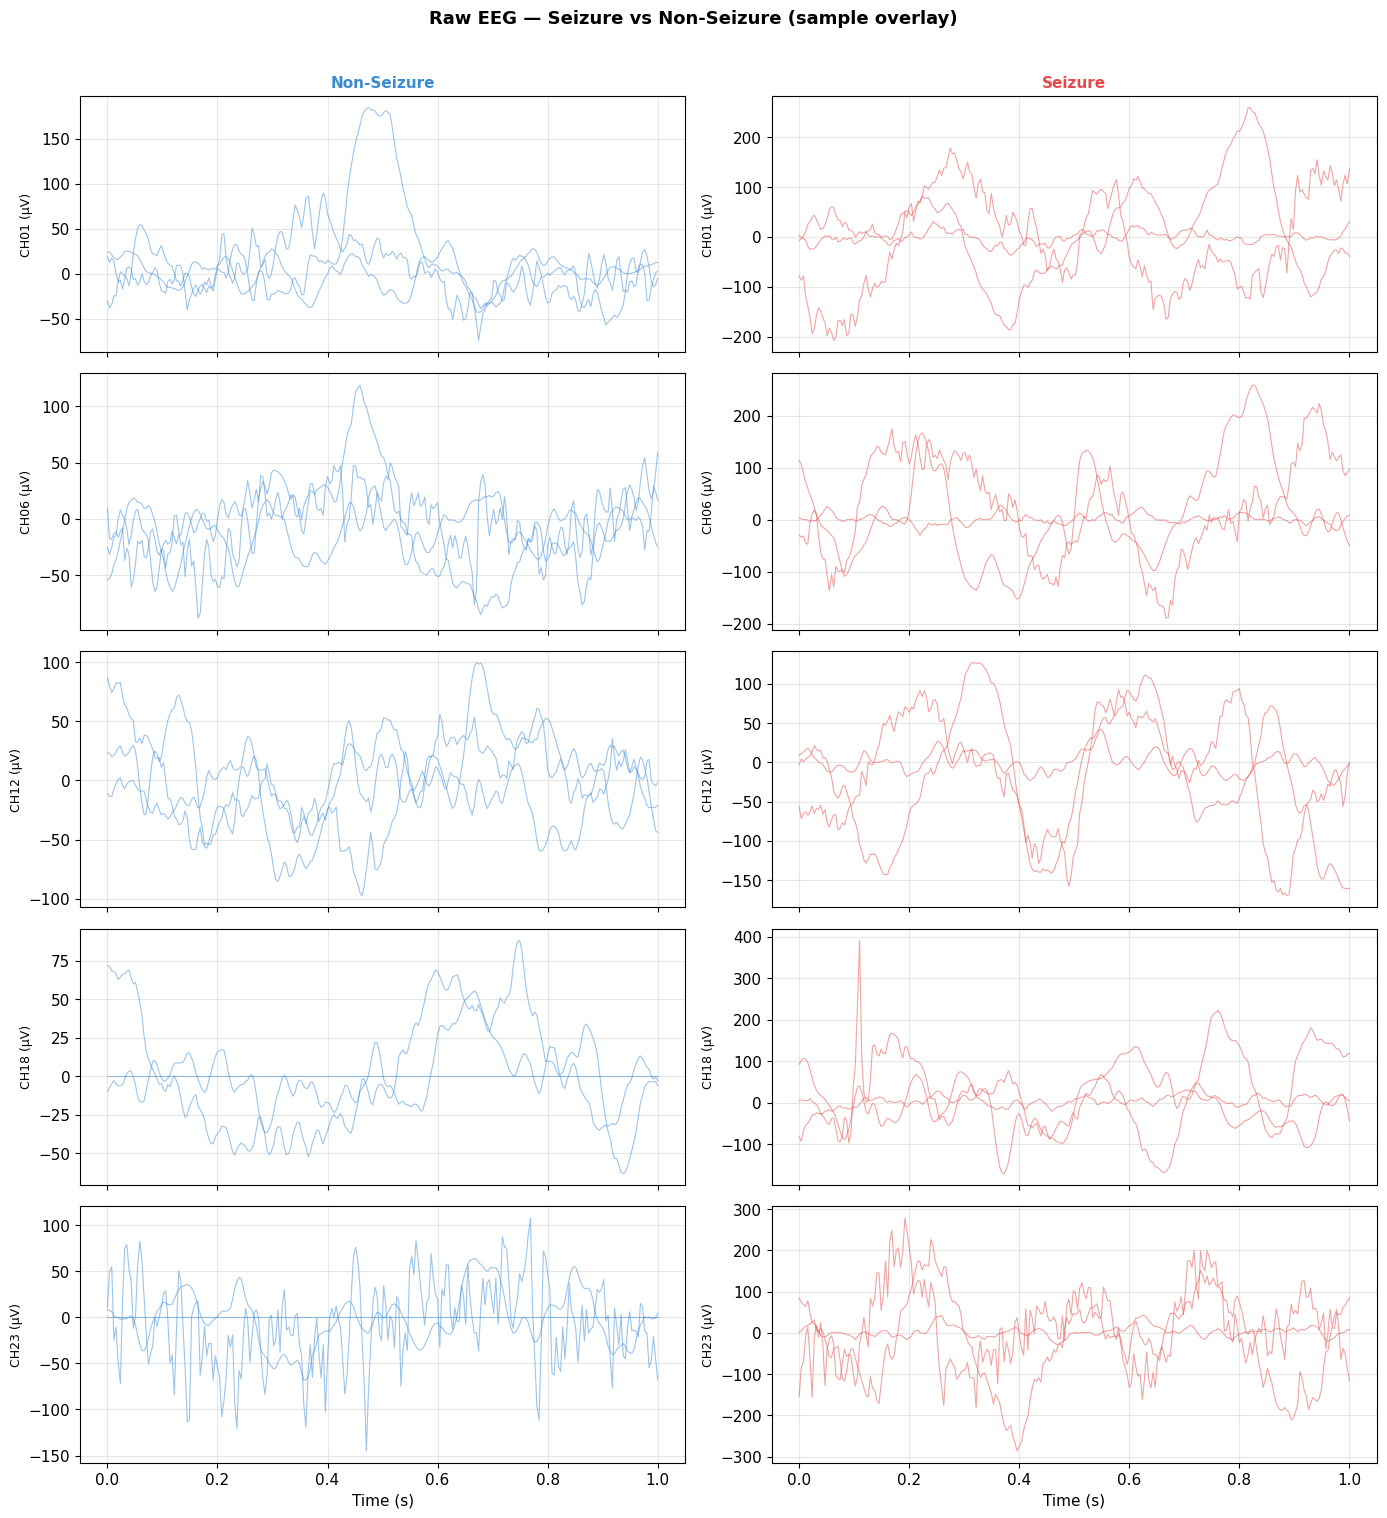

Saved: 01_raw_signals.png

PLOT 2 — FFT power spectrum


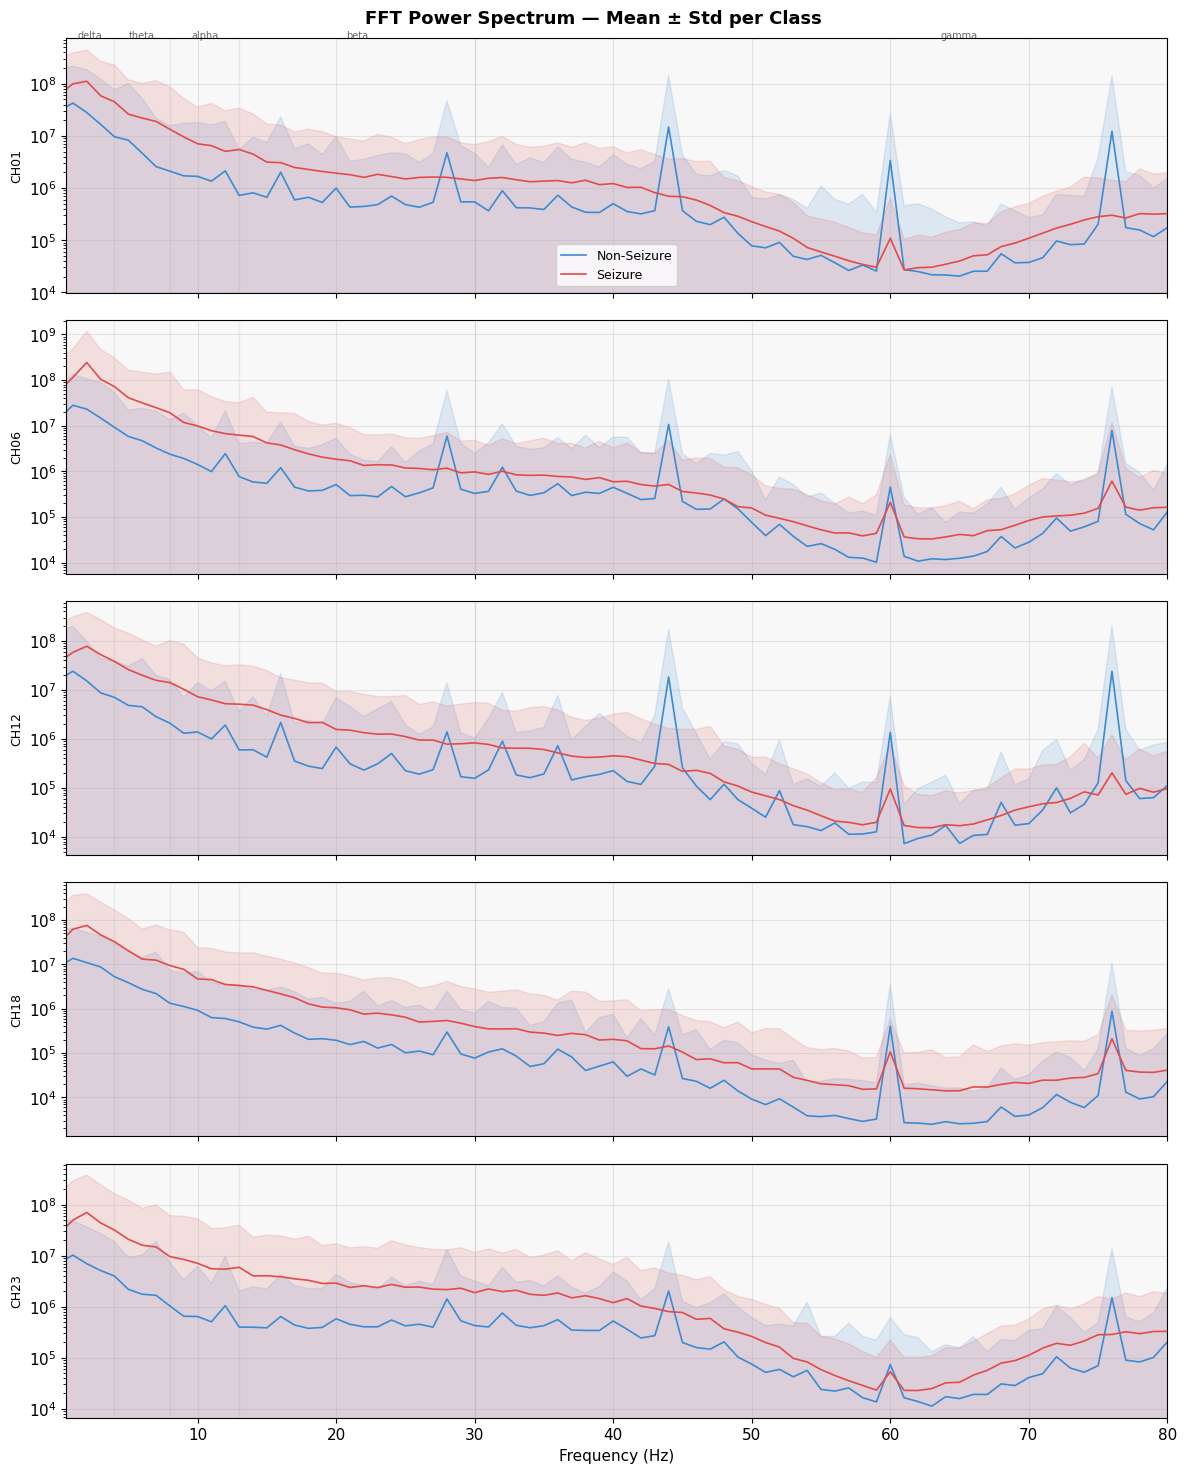

Saved: 02_fft_spectrum.png

PLOT 3 — Band power heatmap (uses train set for N)
Computing band power (this takes ~1–2 min on full train set)...


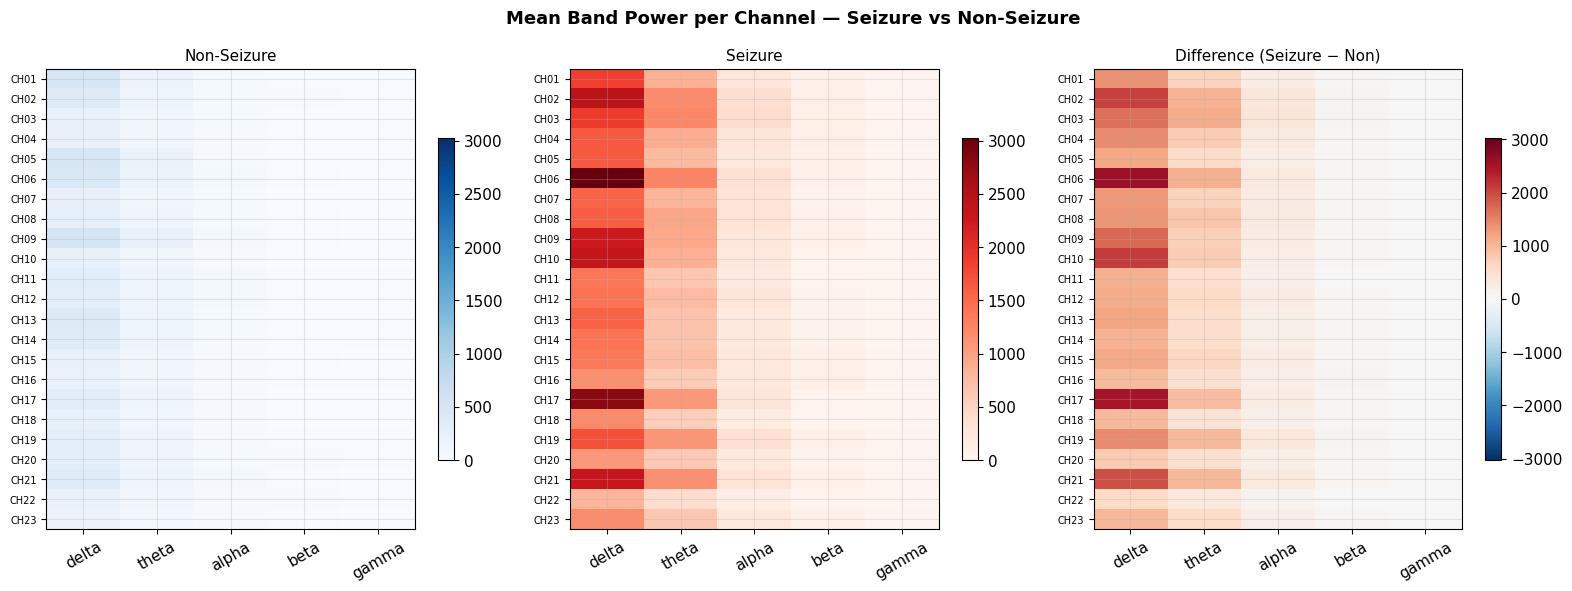

Saved: 03_band_power_heatmap.png

PLOT 4 — Channel discriminability


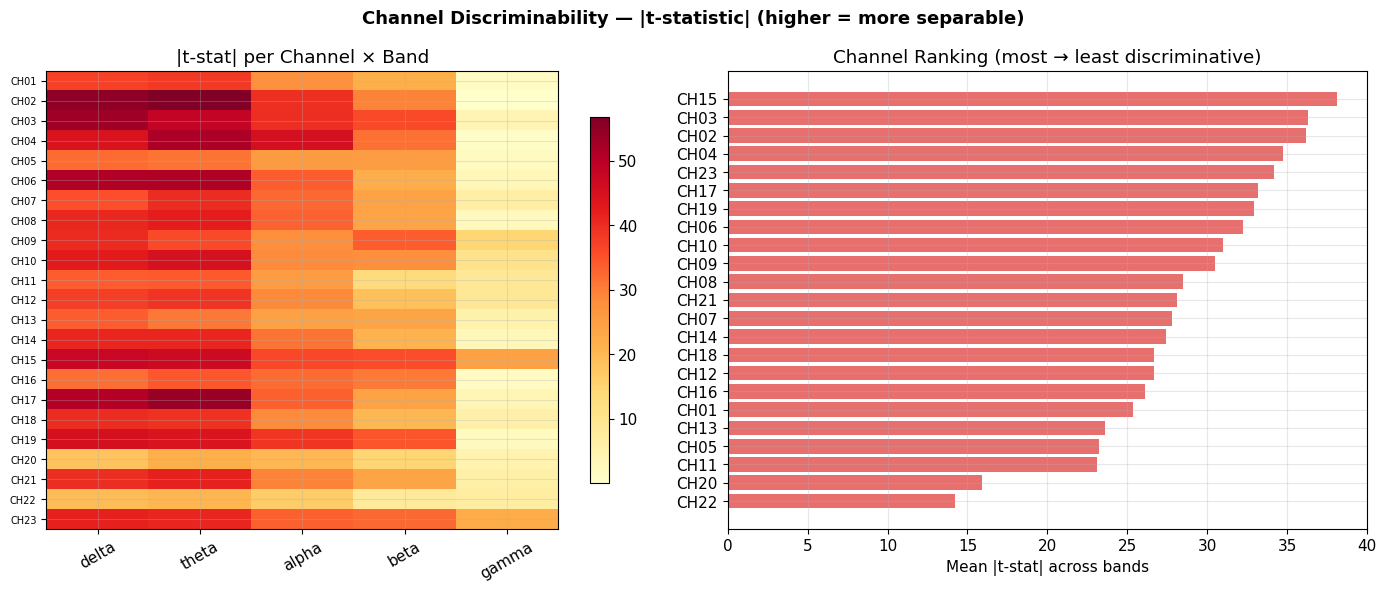

Saved: 04_channel_discriminability.png

PLOT 5 — Hilbert envelope


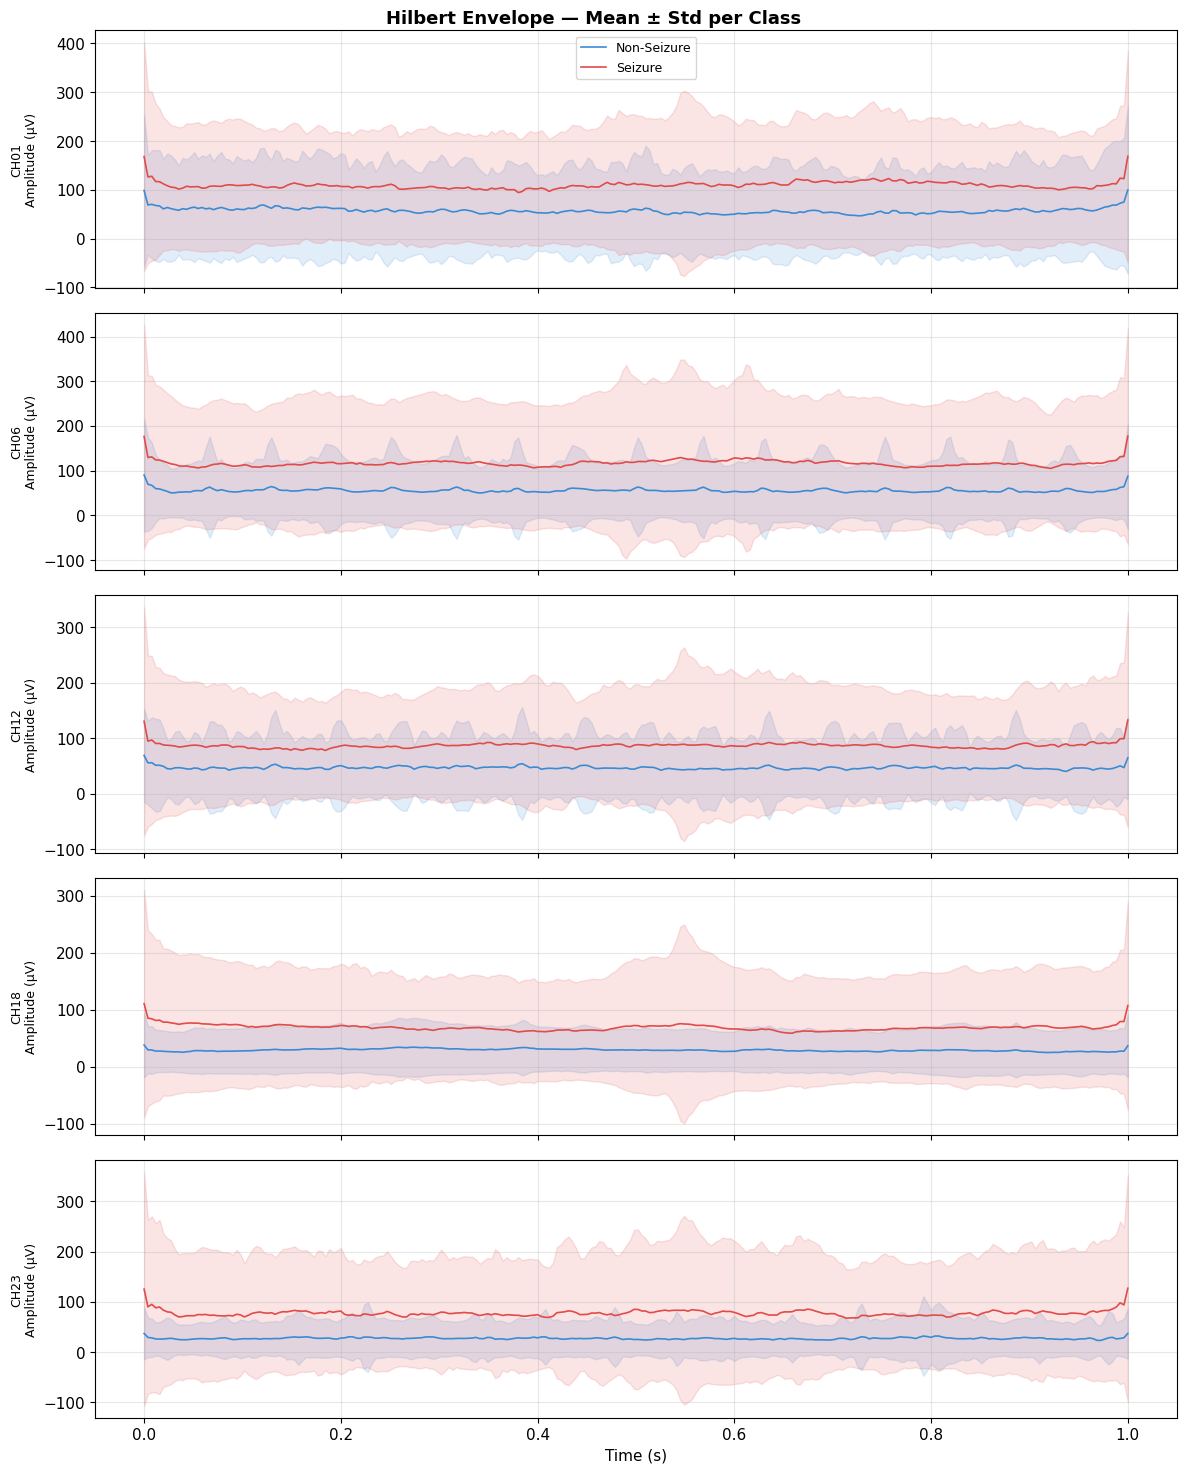

Saved: 05_hilbert_envelope.png

PLOT 6 — Cross-channel correlation matrix


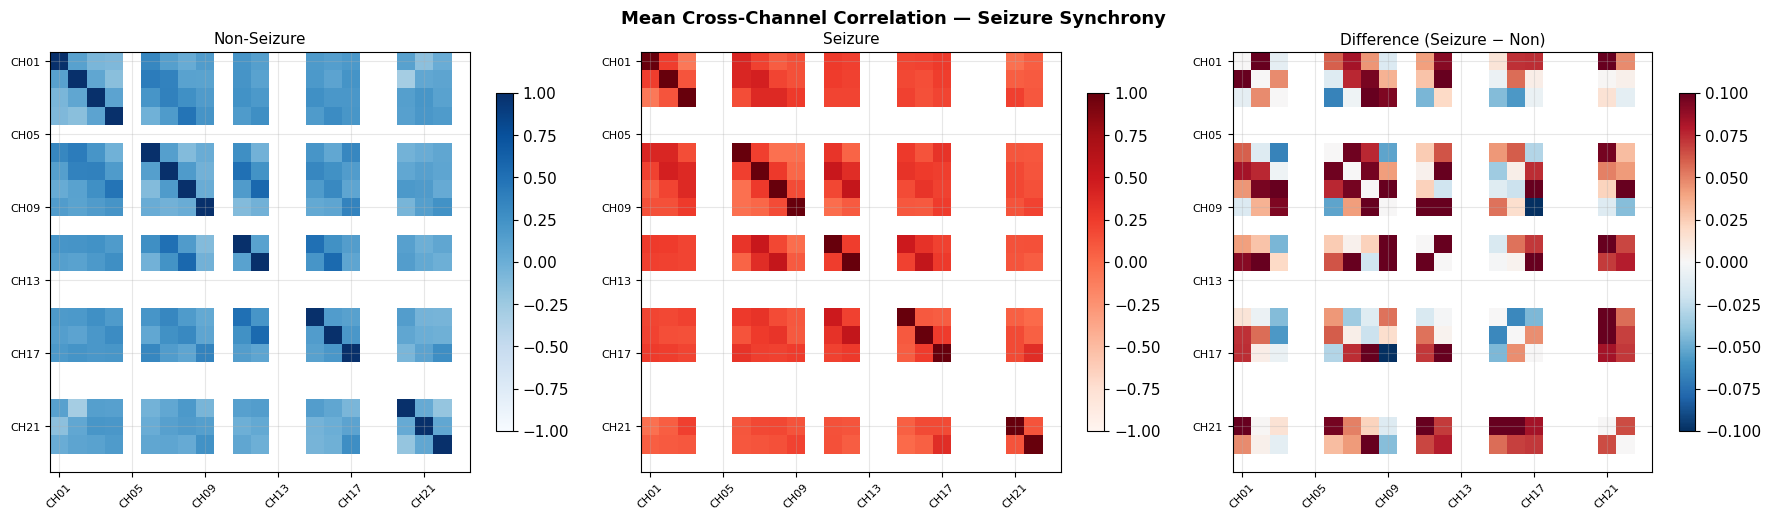

Saved: 06_correlation_matrix.png

>> KEY: If seizure matrix shows brighter off-diagonal blocks,
   channels are synchronising — that IS the seizure signature.

PLOT 7 — Global statistics per channel


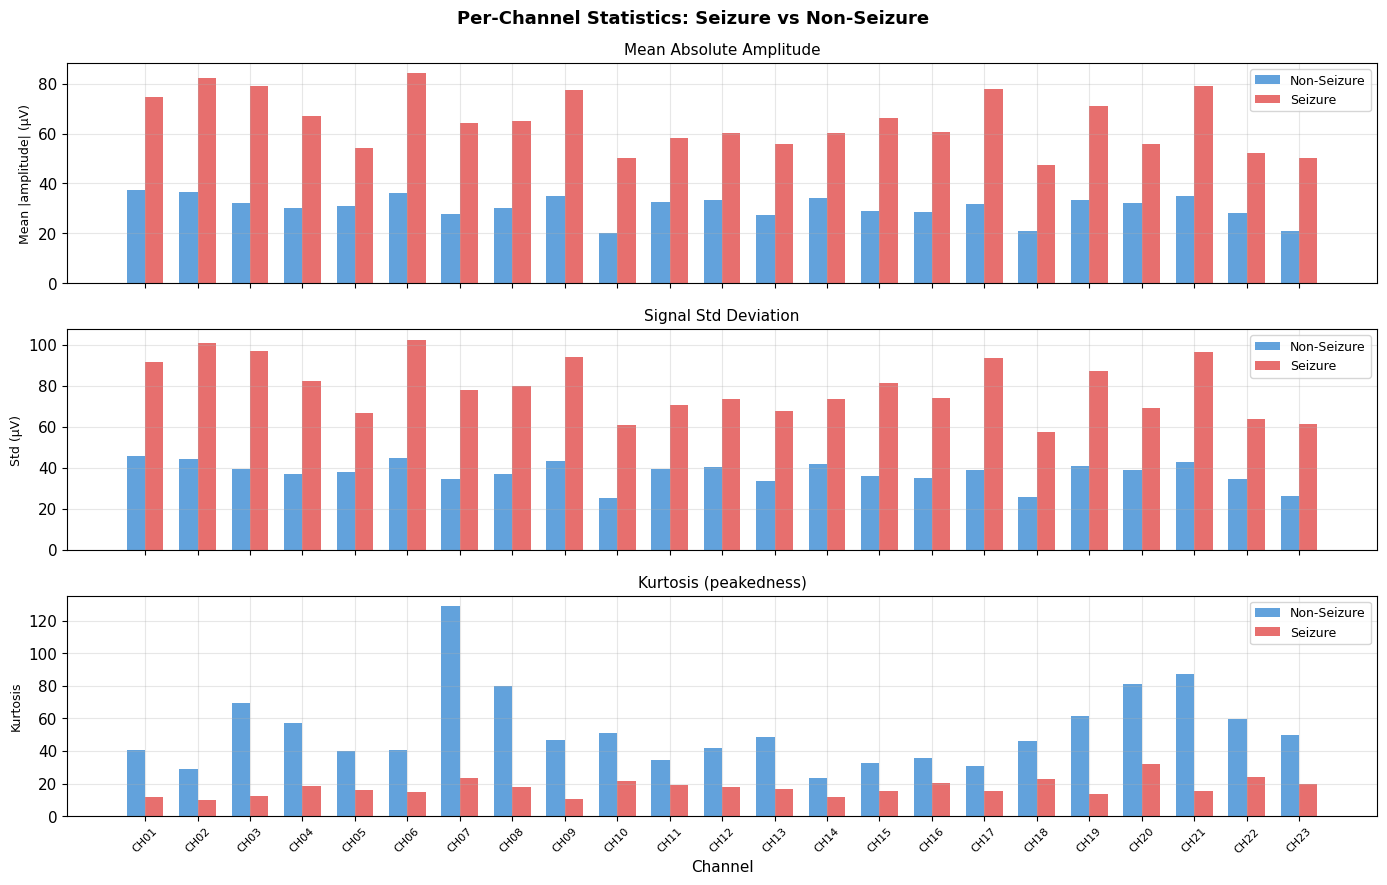

Saved: 07_global_stats.png

✓ All EDA plots saved.


In [3]:
"""
EEG Seizure Detection — EDA
Dataset: CHB-MIT Subdataset (Kaggle)
Input shape per sample: (23, 256) → 23 channels × 256 time points @ 256 Hz = 1 second
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch
from scipy.signal import hilbert
from scipy.fft import fft, fftfreq
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
PATHS = {
    "train":     "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_train.npz",
    "val":       "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val.npz",
    "val_bal":   "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val_balanced.npz",
}

FS        = 256          # Sampling frequency (Hz)
N_CH      = 23           # Number of channels
T         = 256          # Time points per sample
FREQS     = np.fft.rfftfreq(T, d=1/FS)  # Frequency axis for FFT

# Standard EEG frequency bands
BANDS = {
    "delta":  (0.5,  4),
    "theta":  (4,    8),
    "alpha":  (8,   13),
    "beta":   (13,  30),
    "gamma":  (30, 100),
}

# Channel labels (standard 10-20 system approximation for CHB-MIT)
CH_NAMES = [f"CH{i+1:02d}" for i in range(N_CH)]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})


# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
def load_data():
    print("Loading datasets...")
    train   = np.load(PATHS["train"])
    val_bal = np.load(PATHS["val_bal"])

    X_train, y_train = train["train_signals"],   train["train_labels"]
    X_val,   y_val   = val_bal["val_signals"],   val_bal["val_labels"]

    print(f"  Train    → X: {X_train.shape}, y: {y_train.shape} | "
          f"Seizure: {y_train.sum()} / Non-seizure: {(y_train==0).sum()}")
    print(f"  Val(bal) → X: {X_val.shape},   y: {y_val.shape}   | "
          f"Seizure: {y_val.sum()} / Non-seizure: {(y_val==0).sum()}")

    return X_train, y_train, X_val, y_val


# ─────────────────────────────────────────────
# 2. HELPER: compute band power per sample
#    Returns (N, N_CH, n_bands)
# ─────────────────────────────────────────────
def compute_band_power(X):
    """
    X: (N, 23, 256)
    Returns band_power: (N, 23, 5)  — one value per channel per band
    """
    N = X.shape[0]
    band_names = list(BANDS.keys())
    out = np.zeros((N, N_CH, len(band_names)))
    for i in range(N):
        for ch in range(N_CH):
            sig = X[i, ch, :]
            freqs, psd = welch(sig, fs=FS, nperseg=128)
            for b_idx, (bname, (lo, hi)) in enumerate(BANDS.items()):
                mask = (freqs >= lo) & (freqs <= hi)
                out[i, ch, b_idx] = psd[mask].mean()
    return out   # (N, 23, 5)


# ─────────────────────────────────────────────
# 3. PLOT 1 — Raw signal overlay (seizure vs non-seizure)
#             for a few representative channels
# ─────────────────────────────────────────────
def plot_raw_signals(X, y, n_examples=3, channels=[0, 5, 11, 17, 22]):
    seiz_idx   = np.where(y == 1)[0][:n_examples]
    nonseiz_idx = np.where(y == 0)[0][:n_examples]
    t_axis = np.linspace(0, 1, T)

    fig, axes = plt.subplots(len(channels), 2,
                             figsize=(14, 3 * len(channels)),
                             sharex=True)
    fig.suptitle("Raw EEG — Seizure vs Non-Seizure (sample overlay)",
                 fontsize=13, fontweight="bold", y=1.01)

    for row, ch in enumerate(channels):
        for col, (label, indices, color) in enumerate([
            ("Non-Seizure", nonseiz_idx, "#3B8BD4"),
            ("Seizure",     seiz_idx,    "#E24B4A"),
        ]):
            ax = axes[row, col]
            for idx in indices:
                ax.plot(t_axis, X[idx, ch, :], alpha=0.5, lw=0.8, color=color)
            ax.set_ylabel(f"CH{ch+1:02d} (μV)", fontsize=9)
            if row == 0:
                ax.set_title(label, fontsize=11, color=color, fontweight="bold")
            if row == len(channels) - 1:
                ax.set_xlabel("Time (s)")

    plt.tight_layout()
    plt.savefig("01_raw_signals.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: 01_raw_signals.png")


# ─────────────────────────────────────────────
# 4. PLOT 2 — FFT Power Spectrum comparison
#             Mean spectrum across all samples per class
# ─────────────────────────────────────────────
def plot_fft_spectrum(X, y, channels=[0, 5, 11, 17, 22]):
    seiz_idx    = np.where(y == 1)[0]
    nonseiz_idx = np.where(y == 0)[0]
    freq_axis   = FREQS[:T//2 + 1]  # 0–128 Hz

    fig, axes = plt.subplots(len(channels), 1,
                             figsize=(12, 3 * len(channels)), sharex=True)
    fig.suptitle("FFT Power Spectrum — Mean ± Std per Class",
                 fontsize=13, fontweight="bold")

    for row, ch in enumerate(channels):
        ax = axes[row]

        for label, indices, color, ls in [
            ("Non-Seizure", nonseiz_idx, "#3B8BD4", "-"),
            ("Seizure",     seiz_idx,    "#E24B4A", "-"),
        ]:
            specs = []
            for idx in indices:
                sig = X[idx, ch, :]
                power = np.abs(fft(sig))[:T//2 + 1] ** 2
                specs.append(power)
            specs = np.array(specs)
            mean_spec = specs.mean(axis=0)
            std_spec  = specs.std(axis=0)
            ax.semilogy(freq_axis, mean_spec, color=color, lw=1.2, label=label)
            ax.fill_between(freq_axis,
                            mean_spec - std_spec,
                            mean_spec + std_spec,
                            color=color, alpha=0.15)

        # Shade bands
        for bname, (lo, hi) in BANDS.items():
            ax.axvspan(lo, hi, alpha=0.05, color="gray")

        ax.set_ylabel(f"CH{ch+1:02d}", fontsize=9)
        ax.set_xlim(0.5, 80)
        if row == 0:
            ax.legend(fontsize=9)

    axes[-1].set_xlabel("Frequency (Hz)")
    for b, (lo, hi) in BANDS.items():
        axes[0].text((lo+hi)/2, axes[0].get_ylim()[1],
                     b, ha="center", fontsize=7, alpha=0.6)

    plt.tight_layout()
    plt.savefig("02_fft_spectrum.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: 02_fft_spectrum.png")


# ─────────────────────────────────────────────
# 5. PLOT 3 — Band Power Heatmap across all channels
#             (mean band power per channel, seizure vs non-seizure)
# ─────────────────────────────────────────────
def plot_band_power_heatmap(X, y):
    print("Computing band power (this takes ~1–2 min on full train set)...")
    band_power = compute_band_power(X)   # (N, 23, 5)

    seiz_idx    = np.where(y == 1)[0]
    nonseiz_idx = np.where(y == 0)[0]

    bp_seiz    = band_power[seiz_idx].mean(axis=0)    # (23, 5)
    bp_nonseiz = band_power[nonseiz_idx].mean(axis=0) # (23, 5)
    band_names = list(BANDS.keys())

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle("Mean Band Power per Channel — Seizure vs Non-Seizure",
                 fontsize=13, fontweight="bold")

    vmax = max(bp_seiz.max(), bp_nonseiz.max())

    for ax, data, title, cmap in zip(
        axes,
        [bp_nonseiz, bp_seiz, bp_seiz - bp_nonseiz],
        ["Non-Seizure", "Seizure", "Difference (Seizure − Non)"],
        ["Blues", "Reds", "RdBu_r"]
    ):
        im = ax.imshow(data, aspect="auto", cmap=cmap,
                       vmin=-vmax if "Diff" in title else 0,
                       vmax=vmax)
        ax.set_xticks(range(len(band_names)))
        ax.set_xticklabels(band_names, rotation=30)
        ax.set_yticks(range(N_CH))
        ax.set_yticklabels(CH_NAMES, fontsize=7)
        ax.set_title(title, fontsize=11)
        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.tight_layout()
    plt.savefig("03_band_power_heatmap.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: 03_band_power_heatmap.png")
    return band_power


# ─────────────────────────────────────────────
# 6. PLOT 4 — Channel Discriminability (t-test on band power)
#             Shows which channels separate classes best
# ─────────────────────────────────────────────
def plot_channel_discriminability(band_power, y):
    seiz_idx    = np.where(y == 1)[0]
    nonseiz_idx = np.where(y == 0)[0]
    band_names  = list(BANDS.keys())

    # For each channel × band, compute |t-statistic|
    t_stats = np.zeros((N_CH, len(band_names)))
    for ch in range(N_CH):
        for b in range(len(band_names)):
            t, _ = ttest_ind(
                band_power[seiz_idx, ch, b],
                band_power[nonseiz_idx, ch, b],
            )
            t_stats[ch, b] = abs(t)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Channel Discriminability — |t-statistic| (higher = more separable)",
                 fontsize=13, fontweight="bold")

    # Heatmap
    im = axes[0].imshow(t_stats, aspect="auto", cmap="YlOrRd")
    axes[0].set_xticks(range(len(band_names)))
    axes[0].set_xticklabels(band_names, rotation=30)
    axes[0].set_yticks(range(N_CH))
    axes[0].set_yticklabels(CH_NAMES, fontsize=7)
    axes[0].set_title("|t-stat| per Channel × Band")
    plt.colorbar(im, ax=axes[0], shrink=0.8)

    # Bar chart — aggregate across bands
    ch_score = t_stats.mean(axis=1)   # (23,) — mean discriminability across all bands
    sorted_idx = np.argsort(ch_score)[::-1]
    axes[1].barh(
        [CH_NAMES[i] for i in sorted_idx],
        ch_score[sorted_idx],
        color="#E24B4A", alpha=0.8
    )
    axes[1].set_xlabel("Mean |t-stat| across bands")
    axes[1].set_title("Channel Ranking (most → least discriminative)")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig("04_channel_discriminability.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: 04_channel_discriminability.png")


# ─────────────────────────────────────────────
# 7. PLOT 5 — Hilbert Envelope Analysis
#             Instantaneous amplitude envelope per class
# ─────────────────────────────────────────────
def plot_hilbert_envelope(X, y, channels=[0, 5, 11, 17, 22]):
    seiz_idx    = np.where(y == 1)[0]
    nonseiz_idx = np.where(y == 0)[0]
    t_axis      = np.linspace(0, 1, T)

    fig, axes = plt.subplots(len(channels), 1,
                             figsize=(12, 3 * len(channels)), sharex=True)
    fig.suptitle("Hilbert Envelope — Mean ± Std per Class",
                 fontsize=13, fontweight="bold")

    for row, ch in enumerate(channels):
        ax = axes[row]
        for label, indices, color in [
            ("Non-Seizure", nonseiz_idx, "#3B8BD4"),
            ("Seizure",     seiz_idx,    "#E24B4A"),
        ]:
            envelopes = []
            for idx in indices[:200]:   # subset for speed
                sig = X[idx, ch, :]
                env = np.abs(hilbert(sig))
                envelopes.append(env)
            envelopes = np.array(envelopes)
            mean_env = envelopes.mean(axis=0)
            std_env  = envelopes.std(axis=0)
            ax.plot(t_axis, mean_env, color=color, lw=1.2, label=label)
            ax.fill_between(t_axis,
                            mean_env - std_env,
                            mean_env + std_env,
                            color=color, alpha=0.15)
        ax.set_ylabel(f"CH{ch+1:02d}\nAmplitude (μV)", fontsize=9)
        if row == 0:
            ax.legend(fontsize=9)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.savefig("05_hilbert_envelope.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: 05_hilbert_envelope.png")


# ─────────────────────────────────────────────
# 8. PLOT 6 — Cross-channel Correlation Matrix
#             Mean correlation per class (23 × 23)
#             KEY INSIGHT: seizures show higher synchrony
# ─────────────────────────────────────────────
def plot_correlation_matrix(X, y, n_samples=500):
    seiz_idx    = np.where(y == 1)[0][:n_samples]
    nonseiz_idx = np.where(y == 0)[0][:n_samples]

    def mean_corr(indices):
        corr_sum = np.zeros((N_CH, N_CH))
        for idx in indices:
            corr_sum += np.corrcoef(X[idx])   # (23, 23)
        return corr_sum / len(indices)

    corr_nonseiz = mean_corr(nonseiz_idx)
    corr_seiz    = mean_corr(seiz_idx)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Mean Cross-Channel Correlation — Seizure Synchrony",
                 fontsize=13, fontweight="bold")

    for ax, data, title, cmap in zip(
        axes,
        [corr_nonseiz, corr_seiz, corr_seiz - corr_nonseiz],
        ["Non-Seizure", "Seizure", "Difference (Seizure − Non)"],
        ["Blues", "Reds", "RdBu_r"]
    ):
        vabs = np.abs(data).max()
        im = ax.imshow(data, cmap=cmap,
                       vmin=-vabs if "Diff" in title else -1,
                       vmax=vabs if "Diff" in title else 1)
        ax.set_xticks(range(0, N_CH, 4))
        ax.set_xticklabels(CH_NAMES[::4], rotation=45, fontsize=8)
        ax.set_yticks(range(0, N_CH, 4))
        ax.set_yticklabels(CH_NAMES[::4], fontsize=8)
        ax.set_title(title, fontsize=11)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.savefig("06_correlation_matrix.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: 06_correlation_matrix.png")
    print("\n>> KEY: If seizure matrix shows brighter off-diagonal blocks,")
    print("   channels are synchronising — that IS the seizure signature.")


# ─────────────────────────────────────────────
# 9. PLOT 7 — Global Statistics Summary
#             Mean amplitude, std, kurtosis per class
# ─────────────────────────────────────────────
def plot_global_stats(X, y):
    from scipy.stats import kurtosis

    seiz_idx    = np.where(y == 1)[0]
    nonseiz_idx = np.where(y == 0)[0]

    def channel_stats(indices):
        mean_amp = np.abs(X[indices]).mean(axis=(0, 2))       # (23,)
        std_amp  = X[indices].std(axis=2).mean(axis=0)        # (23,)
        kurt     = np.array([
            kurtosis(X[indices, ch, :].flatten())
            for ch in range(N_CH)
        ])
        return mean_amp, std_amp, kurt

    mean_n, std_n, kurt_n = channel_stats(nonseiz_idx)
    mean_s, std_s, kurt_s = channel_stats(seiz_idx)

    x = np.arange(N_CH)
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle("Per-Channel Statistics: Seizure vs Non-Seizure",
                 fontsize=13, fontweight="bold")

    for ax, (val_n, val_s, ylabel, title) in zip(axes, [
        (mean_n, mean_s, "Mean |amplitude| (μV)", "Mean Absolute Amplitude"),
        (std_n,  std_s,  "Std (μV)",               "Signal Std Deviation"),
        (kurt_n, kurt_s, "Kurtosis",                "Kurtosis (peakedness)"),
    ]):
        w = 0.35
        ax.bar(x - w/2, val_n, width=w, label="Non-Seizure",
               color="#3B8BD4", alpha=0.8)
        ax.bar(x + w/2, val_s, width=w, label="Seizure",
               color="#E24B4A", alpha=0.8)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=9)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(CH_NAMES, rotation=45, fontsize=8)
    axes[-1].set_xlabel("Channel")
    plt.tight_layout()
    plt.savefig("07_global_stats.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: 07_global_stats.png")


# ─────────────────────────────────────────────
# MAIN — Run all EDA steps
# ─────────────────────────────────────────────
if __name__ == "__main__":

    # Load
    X_train, y_train, X_val, y_val = load_data()

    # Use val_balanced for cleaner class-balanced EDA visuals
    # Use X_train/y_train for large-scale stats (band power, corr)
    X, y = X_val, y_val        # balanced → clean class comparisons
    X_big, y_big = X_train, y_train   # large → statistical power

    print("\n" + "="*50)
    print("PLOT 1 — Raw signal overlay")
    print("="*50)
    plot_raw_signals(X, y)

    print("\n" + "="*50)
    print("PLOT 2 — FFT power spectrum")
    print("="*50)
    plot_fft_spectrum(X, y)

    print("\n" + "="*50)
    print("PLOT 3 — Band power heatmap (uses train set for N)")
    print("="*50)
    band_power = plot_band_power_heatmap(X_big, y_big)

    print("\n" + "="*50)
    print("PLOT 4 — Channel discriminability")
    print("="*50)
    plot_channel_discriminability(band_power, y_big)

    print("\n" + "="*50)
    print("PLOT 5 — Hilbert envelope")
    print("="*50)
    plot_hilbert_envelope(X, y)

    print("\n" + "="*50)
    print("PLOT 6 — Cross-channel correlation matrix")
    print("="*50)
    plot_correlation_matrix(X_big, y_big)

    print("\n" + "="*50)
    print("PLOT 7 — Global statistics per channel")
    print("="*50)
    plot_global_stats(X, y)

    print("\n✓ All EDA plots saved.")

  EEG SEIZURE — NAIVE XGBoost BASELINE

[1] Loading data...
  Train raw    : (37666, 23, 256) | class 0: 29592, class 1: 8074
  Val balanced : (3546, 23, 256)       | class 0: 1773,  class 1: 1773

[2] Balancing train set via equal undersampling...
  Balanced train : (16148, 23, 256) | class 0: 8074, class 1: 8074

[3] Flattening (23, 256) → 5888 raw features...
  Feature dim : 5888

[4] Training XGBoost...
  (tree_method=hist for speed on 5888-dim input)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:27:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.66270
[50]	validation_0-logloss:0.36967
[100]	validation_0-logloss:0.33962
[150]	validation_0-logloss:0.32973
[200]	validation_0-logloss:0.32403
[250]	validation_0-logloss:0.32412
[299]	validation_0-logloss:0.32523

  Training time: 262.2s

[5] Evaluating on Val (balanced)...

  RESULTS — Validation Balanced (Test Set)
                 precision    recall  f1-score   support

Non-Seizure (0)     0.8741    0.8539    0.8639      1773
    Seizure (1)     0.8572    0.8770    0.8670      1773

       accuracy                         0.8655      3546
      macro avg     0.8657    0.8655    0.8655      3546
   weighted avg     0.8657    0.8655    0.8655      3546

  ROC-AUC : 0.9376

  Confusion Matrix:
                        Pred 0    Pred 1
  Actual 0 (Non-Seiz)     1514       259
  Actual 1 (Seizure)       218      1555


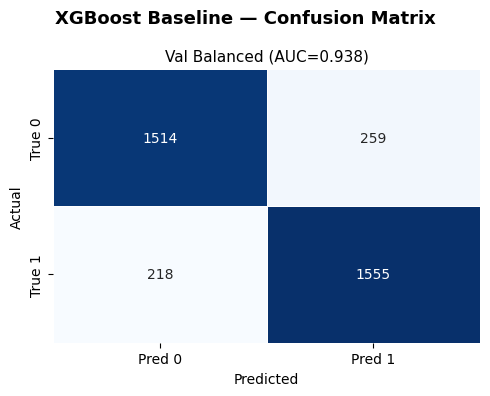


Saved: xgb_baseline_confusion.png

  BASELINE SUMMARY
  Model       : XGBoost (300 trees, depth 6)
  Features    : Raw flattened signal (5888 dims)
  Train size  : 16148 balanced samples
  Val AUC     : 0.9376

  → This is the FLOOR. Any engineered feature model should beat this.
  → Next step: band power + Hilbert features → same XGBoost → compare AUC.


In [3]:
"""
Naive XGBoost Baseline — EEG Seizure Detection
Features : raw flattened signal (23 × 256 = 5888 dims), zero engineering
Sampling : equal class balance from train set (undersample majority)
Eval     : val_balanced only (used as test set)
"""

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ─────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────
PATHS = {
    "train":   "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_train.npz",
    "val_bal": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val_balanced.npz",
}

# ─────────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────────
print("=" * 55)
print("  EEG SEIZURE — NAIVE XGBoost BASELINE")
print("=" * 55)

print("\n[1] Loading data...")

train   = np.load(PATHS["train"])
val_bal = np.load(PATHS["val_bal"])

X_train_raw, y_train = train["train_signals"],  train["train_labels"]
X_val,       y_val   = val_bal["val_signals"],  val_bal["val_labels"]

print(f"  Train raw    : {X_train_raw.shape} | "
      f"class 0: {(y_train==0).sum()}, class 1: {(y_train==1).sum()}")
print(f"  Val balanced : {X_val.shape}       | "
      f"class 0: {(y_val==0).sum()},  class 1: {(y_val==1).sum()}")

# ─────────────────────────────────────────────
# 2. EQUAL SAMPLING FROM TRAIN SET
#    Undersample majority class (0) to match minority (1)
# ─────────────────────────────────────────────
print("\n[2] Balancing train set via equal undersampling...")

idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
n_minority = len(idx_1)

np.random.seed(42)
idx_0_sampled = np.random.choice(idx_0, size=n_minority, replace=False)
idx_balanced  = np.concatenate([idx_0_sampled, idx_1])
np.random.shuffle(idx_balanced)

X_bal = X_train_raw[idx_balanced]   # (2 × n_minority, 23, 256)
y_bal = y_train[idx_balanced]

print(f"  Balanced train : {X_bal.shape} | "
      f"class 0: {(y_bal==0).sum()}, class 1: {(y_bal==1).sum()}")

# ─────────────────────────────────────────────
# 3. FLATTEN — (N, 23, 256) → (N, 5888)
#    Zero feature engineering, purely raw signal
# ─────────────────────────────────────────────
print("\n[3] Flattening (23, 256) → 5888 raw features...")

X_train_flat = X_bal.reshape(len(X_bal), -1).astype(np.float32)
X_val_flat   = X_val.reshape(len(X_val), -1).astype(np.float32)

print(f"  Feature dim : {X_train_flat.shape[1]}")

# ─────────────────────────────────────────────
# 4. TRAIN XGBoost
# ─────────────────────────────────────────────
print("\n[4] Training XGBoost...")
print("  (tree_method=hist for speed on 5888-dim input)")

model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.3,   # sample 30% of 5888 features per tree → manageable
    tree_method       = "hist",
    use_label_encoder = False,
    eval_metric       = "logloss",
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 1,
)

t0 = time.time()
model.fit(
    X_train_flat, y_bal,
    eval_set=[(X_val_flat, y_val)],
    verbose=50,
)
elapsed = time.time() - t0
print(f"\n  Training time: {elapsed:.1f}s")

# ─────────────────────────────────────────────
# 5. EVALUATE
# ─────────────────────────────────────────────
def evaluate(X_flat, y_true, split_name):
    y_pred  = model.predict(X_flat)
    y_proba = model.predict_proba(X_flat)[:, 1]
    auc     = roc_auc_score(y_true, y_proba)
    cm      = confusion_matrix(y_true, y_pred)
    report  = classification_report(
        y_true, y_pred,
        target_names=["Non-Seizure (0)", "Seizure (1)"],
        digits=4
    )

    print(f"\n{'='*55}")
    print(f"  RESULTS — {split_name}")
    print(f"{'='*55}")
    print(report)
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  {'':20s}  Pred 0    Pred 1")
    print(f"  {'Actual 0 (Non-Seiz)':20s}  {cm[0,0]:6d}    {cm[0,1]:6d}")
    print(f"  {'Actual 1 (Seizure)':20s}  {cm[1,0]:6d}    {cm[1,1]:6d}")

    return y_pred, y_proba, cm, auc

print("\n[5] Evaluating on Val (balanced)...")

_, _, cm_val, auc_val = evaluate(X_val_flat, y_val, "Validation Balanced (Test Set)")

# ─────────────────────────────────────────────
# 6. CONFUSION MATRIX PLOT
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
fig.suptitle("XGBoost Baseline — Confusion Matrix", fontsize=13, fontweight="bold")

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
            cbar=False, linewidths=0.5)
ax.set_title(f"Val Balanced (AUC={auc_val:.3f})", fontsize=11)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("xgb_baseline_confusion.png", dpi=130, bbox_inches="tight")
plt.show()
print("\nSaved: xgb_baseline_confusion.png")

# ─────────────────────────────────────────────
# 7. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  BASELINE SUMMARY")
print("="*55)
print(f"  Model       : XGBoost (300 trees, depth 6)")
print(f"  Features    : Raw flattened signal (5888 dims)")
print(f"  Train size  : {len(X_train_flat)} balanced samples")
print(f"  Val AUC     : {auc_val:.4f}")
print("\n  → This is the FLOOR. Any engineered feature model should beat this.")
print("  → Next step: band power + Hilbert features → same XGBoost → compare AUC.")

  EEG SEIZURE — FREQUENCY DOMAIN XGBoost

[1] Loading data...
  Train : (37666, 23, 256) | 0: 29592, 1: 8074
  Val   : (3546, 23, 256)       | 0: 1773,  1: 1773

[2] Balancing train set...
  Balanced: (16148, 23, 256) | 0: 8074, 1: 8074

[3] Extracting frequency features...
  Extracting frequency features from 16148 samples (train balanced)...
    2000/16148  (12%)  elapsed: 22s
    4000/16148  (25%)  elapsed: 44s
    6000/16148  (37%)  elapsed: 66s
    8000/16148  (50%)  elapsed: 89s
    10000/16148  (62%)  elapsed: 111s
    12000/16148  (74%)  elapsed: 133s
    14000/16148  (87%)  elapsed: 154s
    16000/16148  (99%)  elapsed: 176s
  Done in 177.5s  |  feature shape: (16148, 230)
  Extracting frequency features from 3546 samples (val balanced)...
    2000/3546  (56%)  elapsed: 22s
  Done in 38.5s  |  feature shape: (3546, 230)

  Feature matrix shapes:
  Train : (16148, 230)  ← 230 = 115 abs + 115 relative band power
  Val   : (3546, 230)

[4] Training XGBoost on 230 frequency featur

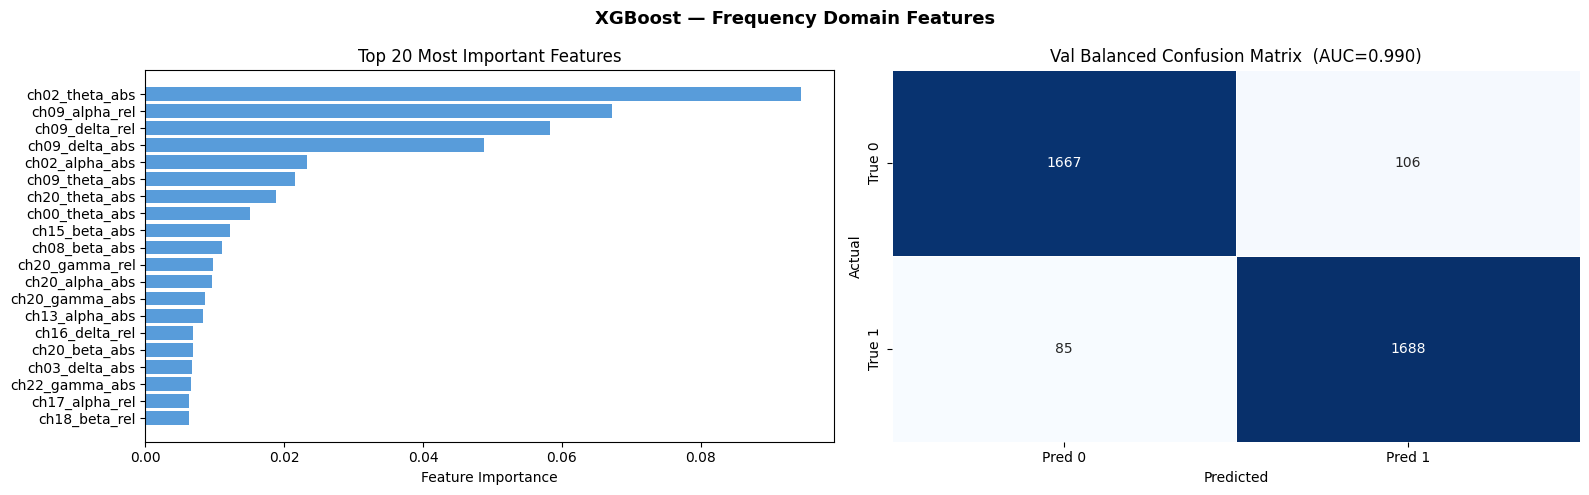

Saved: xgb_freq_features.png

  SUMMARY
  Features    : 230  (115 abs + 115 relative band power)
  vs Baseline : 5888 (raw flattened)
  Val  AUC    : 0.9897

  Top 5 most important features:
    ch02_theta_abs                  importance: 0.0944
    ch09_alpha_rel                  importance: 0.0672
    ch09_delta_rel                  importance: 0.0583
    ch09_delta_abs                  importance: 0.0488
    ch02_alpha_abs                  importance: 0.0233


In [2]:
"""
XGBoost — Frequency Domain Features Only
Features : band power (5 bands × 23 channels = 115 dims)
           + relative band power (115 dims)
           = 230 total features
Sampling : equal class balance from train set
Eval     : val_balanced only (used as test set)
"""

import numpy as np
from scipy.signal import welch
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ─────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────
PATHS = {
    "train":   "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_train.npz",
    "val_bal": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val_balanced.npz",
}

FS = 256
N_CH = 23

BANDS = {
    "delta": (0.5,  4),
    "theta": (4,    8),
    "alpha": (8,   13),
    "beta":  (13,  30),
    "gamma": (30, 100),
}
BAND_NAMES = list(BANDS.keys())


# ─────────────────────────────────────────────
# FEATURE EXTRACTION
# Input  : X of shape (N, 23, 256)
# Output : feature matrix of shape (N, 230)
#
# For each sample:
#   Step 1 — run Welch PSD on each of the 23 channels
#             → gives power spectral density at each freq bin
#   Step 2 — sum power within each of 5 freq bands per channel
#             → absolute band power: (23 channels × 5 bands) = 115 values
#   Step 3 — divide each band power by total power for that channel
#             → relative band power: another 115 values
#   Step 4 — concatenate absolute + relative → 230-dim vector
#
# Final feature layout (per sample):
#   [ch0_delta, ch0_theta, ch0_alpha, ch0_beta, ch0_gamma,
#    ch1_delta, ..., ch22_gamma,           ← 115 absolute
#    ch0_delta_rel, ..., ch22_gamma_rel]   ← 115 relative
#   = 230 features total
# ─────────────────────────────────────────────
def extract_freq_features(X, desc=""):
    N = X.shape[0]
    n_bands = len(BANDS)
    abs_bp  = np.zeros((N, N_CH, n_bands), dtype=np.float32)

    print(f"  Extracting frequency features from {N} samples {desc}...")
    t0 = time.time()

    for i in range(N):
        for ch in range(N_CH):
            freqs, psd = welch(X[i, ch], fs=FS, nperseg=128)
            for b, (bname, (lo, hi)) in enumerate(BANDS.items()):
                mask = (freqs >= lo) & (freqs <= hi)
                abs_bp[i, ch, b] = psd[mask].mean()

        if (i + 1) % 2000 == 0:
            pct = (i + 1) / N * 100
            print(f"    {i+1}/{N}  ({pct:.0f}%)  "
                  f"elapsed: {time.time()-t0:.0f}s")

    # abs_bp shape: (N, 23, 5)
    # Flatten to (N, 115)
    abs_flat = abs_bp.reshape(N, -1)

    # Relative band power: each band / total power per channel
    total_power = abs_bp.sum(axis=2, keepdims=True)        # (N, 23, 1)
    total_power = np.clip(total_power, 1e-10, None)        # avoid div by zero
    rel_bp      = abs_bp / total_power                     # (N, 23, 5)
    rel_flat    = rel_bp.reshape(N, -1)                    # (N, 115)

    # Concatenate → (N, 230)
    features = np.concatenate([abs_flat, rel_flat], axis=1)

    print(f"  Done in {time.time()-t0:.1f}s  |  feature shape: {features.shape}")
    return features


# ─────────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────────
print("=" * 55)
print("  EEG SEIZURE — FREQUENCY DOMAIN XGBoost")
print("=" * 55)

print("\n[1] Loading data...")
train   = np.load(PATHS["train"])
val_bal = np.load(PATHS["val_bal"])

X_train_raw, y_train = train["train_signals"],  train["train_labels"]
X_val,       y_val   = val_bal["val_signals"],  val_bal["val_labels"]

print(f"  Train : {X_train_raw.shape} | 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
print(f"  Val   : {X_val.shape}       | 0: {(y_val==0).sum()},  1: {(y_val==1).sum()}")

# ─────────────────────────────────────────────
# 2. BALANCE TRAIN SET
# ─────────────────────────────────────────────
print("\n[2] Balancing train set...")

idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
np.random.seed(42)
idx_0_sampled = np.random.choice(idx_0, size=len(idx_1), replace=False)
idx_balanced  = np.concatenate([idx_0_sampled, idx_1])
np.random.shuffle(idx_balanced)

X_bal = X_train_raw[idx_balanced]
y_bal = y_train[idx_balanced]
print(f"  Balanced: {X_bal.shape} | 0: {(y_bal==0).sum()}, 1: {(y_bal==1).sum()}")

# ─────────────────────────────────────────────
# 3. EXTRACT FEATURES
# ─────────────────────────────────────────────
print("\n[3] Extracting frequency features...")
X_train_feat = extract_freq_features(X_bal,  "(train balanced)")
X_val_feat   = extract_freq_features(X_val,  "(val balanced)")

print(f"\n  Feature matrix shapes:")
print(f"  Train : {X_train_feat.shape}  ← 230 = 115 abs + 115 relative band power")
print(f"  Val   : {X_val_feat.shape}")

# ─────────────────────────────────────────────
# 4. TRAIN
# ─────────────────────────────────────────────
print("\n[4] Training XGBoost on 230 frequency features...")

model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,   # 230 features — can afford higher column sampling
    tree_method      = "hist",
    eval_metric      = "logloss",
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 1,
)

t0 = time.time()
model.fit(
    X_train_feat, y_bal,
    eval_set=[(X_val_feat, y_val)],
    verbose=50,
)
print(f"\n  Training time: {time.time()-t0:.1f}s")

# ─────────────────────────────────────────────
# 5. EVALUATE
# ─────────────────────────────────────────────
def evaluate(X_feat, y_true, split_name):
    y_pred  = model.predict(X_feat)
    y_proba = model.predict_proba(X_feat)[:, 1]
    auc     = roc_auc_score(y_true, y_proba)
    cm      = confusion_matrix(y_true, y_pred)
    report  = classification_report(
        y_true, y_pred,
        target_names=["Non-Seizure (0)", "Seizure (1)"],
        digits=4
    )
    print(f"\n{'='*55}")
    print(f"  RESULTS — {split_name}")
    print(f"{'='*55}")
    print(report)
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  {'':20s}  Pred 0    Pred 1")
    print(f"  {'Actual 0 (Non-Seiz)':20s}  {cm[0,0]:6d}    {cm[0,1]:6d}")
    print(f"  {'Actual 1 (Seizure)':20s}  {cm[1,0]:6d}    {cm[1,1]:6d}")
    return y_pred, y_proba, cm, auc

print("\n[5] Evaluating on Val (balanced)...")
_, _, cm_val, auc_val = evaluate(X_val_feat, y_val, "Validation Balanced (Test Set)")

# ─────────────────────────────────────────────
# 6. FEATURE IMPORTANCE — top 20
# ─────────────────────────────────────────────
print("\n[6] Feature importance — top 20...")

# Build feature names: ch00_delta_abs, ch00_theta_abs, ..., ch22_gamma_rel
feat_names = []
for ch in range(N_CH):
    for b in BAND_NAMES:
        feat_names.append(f"ch{ch:02d}_{b}_abs")
for ch in range(N_CH):
    for b in BAND_NAMES:
        feat_names.append(f"ch{ch:02d}_{b}_rel")

importances = model.feature_importances_
top20_idx   = np.argsort(importances)[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("XGBoost — Frequency Domain Features", fontsize=13, fontweight="bold")

axes[0].barh(
    [feat_names[i] for i in top20_idx][::-1],
    importances[top20_idx][::-1],
    color="#3B8BD4", alpha=0.85
)
axes[0].set_xlabel("Feature Importance")
axes[0].set_title("Top 20 Most Important Features")

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
            cbar=False, linewidths=0.5)
axes[1].set_title(f"Val Balanced Confusion Matrix  (AUC={auc_val:.3f})")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("xgb_freq_features.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: xgb_freq_features.png")

# ─────────────────────────────────────────────
# 7. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  SUMMARY")
print("="*55)
print(f"  Features    : 230  (115 abs + 115 relative band power)")
print(f"  vs Baseline : 5888 (raw flattened)")
print(f"  Val  AUC    : {auc_val:.4f}")
print("\n  Top 5 most important features:")
for i in top20_idx[:5]:
    print(f"    {feat_names[i]:30s}  importance: {importances[i]:.4f}")

  EEG SEIZURE — MULTI-MODEL FREQUENCY FEATURE BENCHMARK

[1] Loading data...
  Train (balanced) : (16148, 23, 256) | 0: 8074, 1: 8074
  Val  (balanced)  : (3546, 23, 256) | 0: 1773, 1: 1773

[2] Extracting frequency features...
  Extracting features: 16148 samples (train)...
    2000/16148  (12%)  22s
    4000/16148  (25%)  43s
    6000/16148  (37%)  65s
    8000/16148  (50%)  86s
    10000/16148  (62%)  107s
    12000/16148  (74%)  129s
    14000/16148  (87%)  150s
    16000/16148  (99%)  171s
  Done in 173.1s
  Extracting features: 3546 samples (val)...
    2000/3546  (56%)  21s
  Done in 37.5s

  Train features : (16148, 230)
  Val   features : (3546, 230)

[3] Training and evaluating all models...

Model                      AUC     Acc      F1   Recall    Prec    Time
-----------------------------------------------------------------
XGBoost                 0.9897  0.9461  0.9465   0.9521  0.9409   10.2s
LightGBM                0.9882  0.9453  0.9454   0.9475  0.9433    3.8s
CatBoo

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression      0.8721  0.7953  0.7851   0.7479  0.8262    6.4s
SVM (RBF)               0.8929  0.7730  0.7362   0.6334  0.8787  159.9s
MLP                     0.9488  0.8973  0.8965   0.8895  0.9037   16.9s


  FULL CLASSIFICATION REPORTS

── XGBoost ─────────────────────────────────
                 precision    recall  f1-score   support

Non-Seizure (0)     0.9515    0.9402    0.9458      1773
    Seizure (1)     0.9409    0.9521    0.9465      1773

       accuracy                         0.9461      3546
      macro avg     0.9462    0.9461    0.9461      3546
   weighted avg     0.9462    0.9461    0.9461      3546

  Confusion Matrix:
                        Pred 0    Pred 1
  Actual 0 (Non-Seiz)     1667       106
  Actual 1 (Seizure)        85      1688

── LightGBM ─────────────────────────────────
                 precision    recall  f1-score   support

Non-Seizure (0)     0.9473    0.9430    0.9452      1773
    Seizure (1)     0.9433    0.9475    0.9454      1773

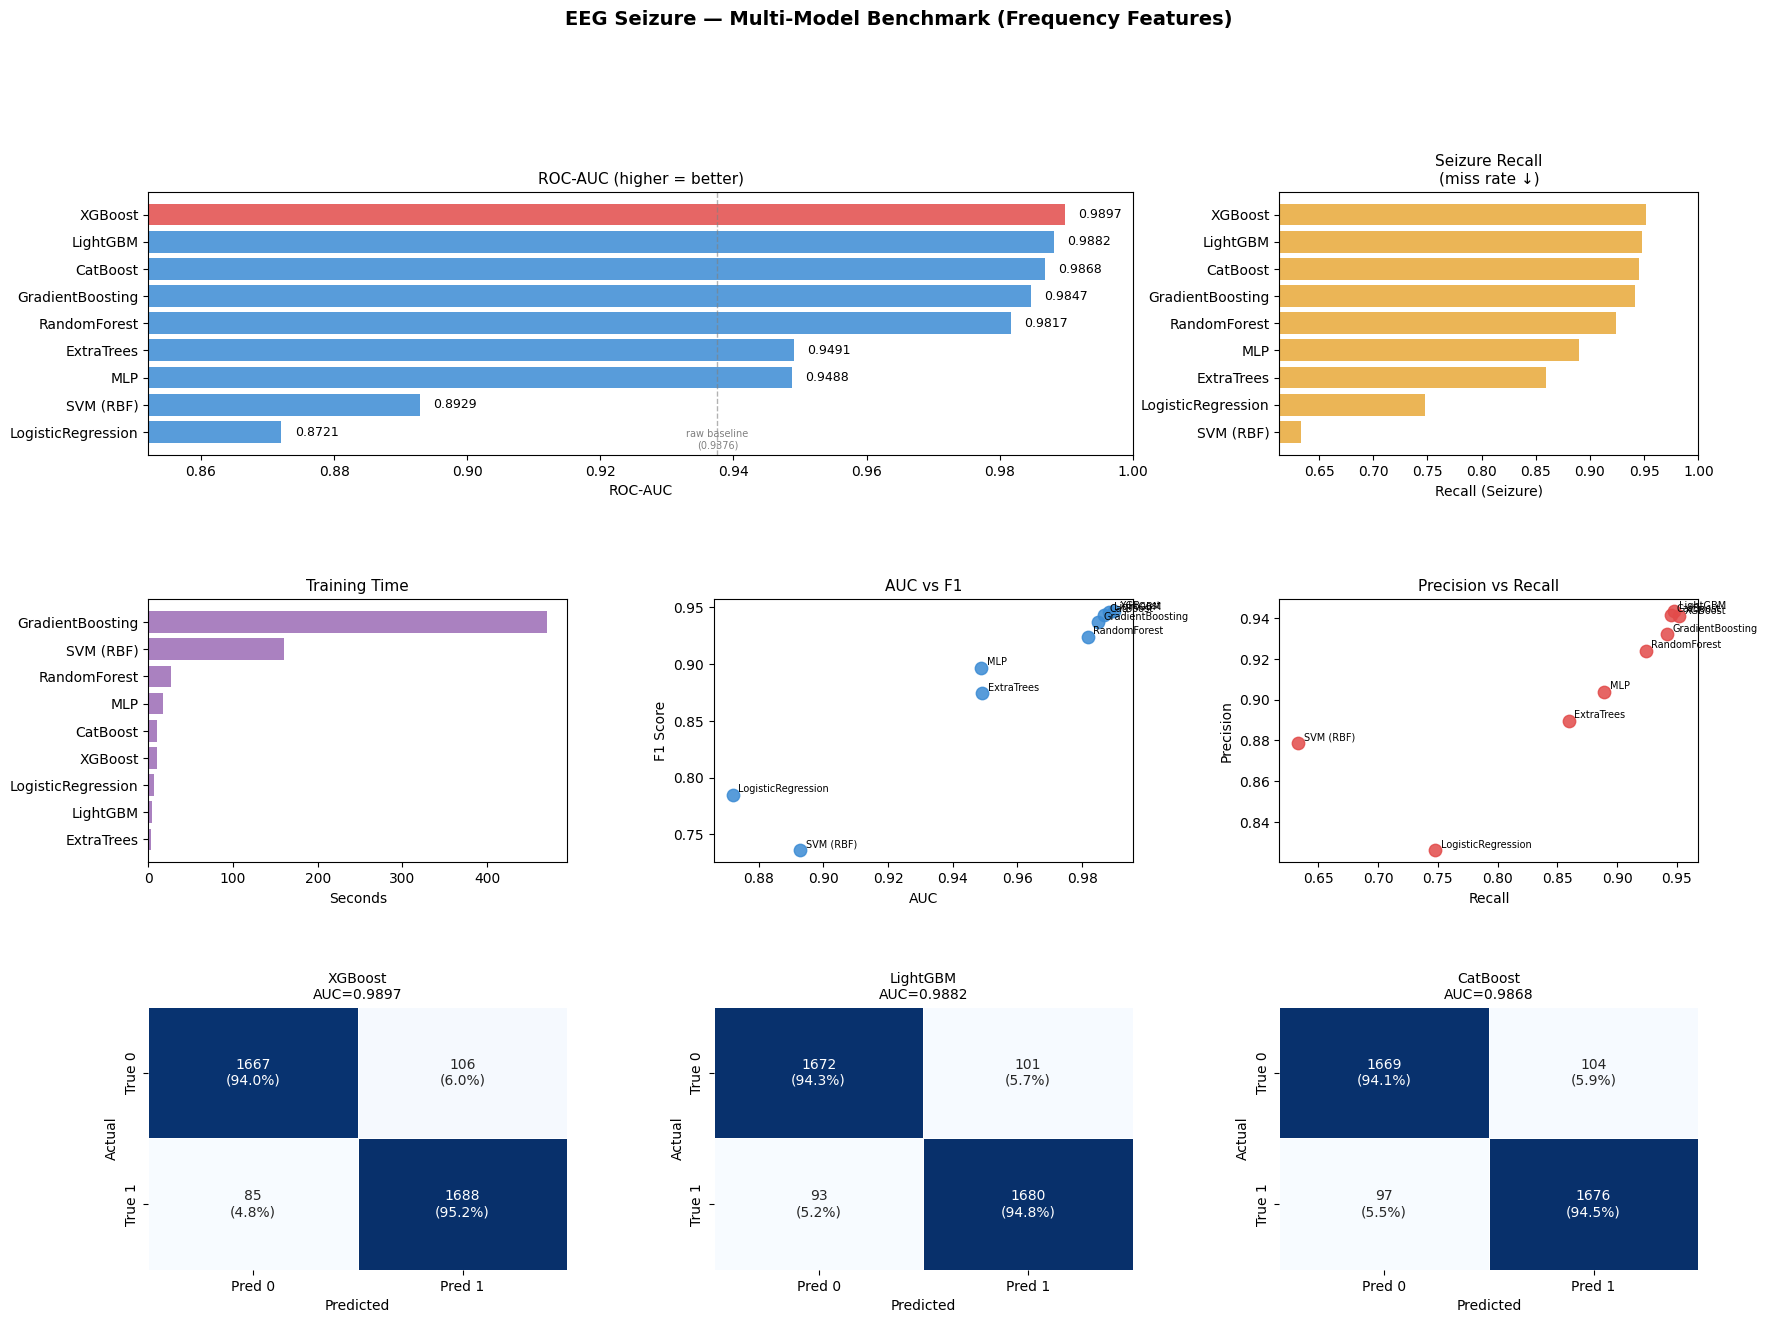


Saved: multi_model_benchmark.png

✓ Done.


In [5]:
"""
EEG Seizure — Frequency Domain Feature Benchmark
Models : XGBoost, LightGBM, CatBoost, RandomForest, ExtraTrees,
         LogisticRegression, SVM (RBF), MLP
Features: 230-dim band power (115 abs + 115 relative)
Eval    : val_balanced only
"""

import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

from scipy.signal import welch

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics + viz
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

# ─────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────
PATHS = {
    "train":   "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_train.npz",
    "val_bal": "/kaggle/input/datasets/adibadea/chbmitseizuredataset/eeg-seizure_val_balanced.npz",
}

FS       = 256
N_CH     = 23
BANDS    = {
    "delta": (0.5,  4),
    "theta": (4,    8),
    "alpha": (8,   13),
    "beta":  (13,  30),
    "gamma": (30, 100),
}
BAND_NAMES = list(BANDS.keys())


# ─────────────────────────────────────────────
# FEATURE EXTRACTION  (same as before)
# ─────────────────────────────────────────────
def extract_freq_features(X, desc=""):
    N      = X.shape[0]
    n_b    = len(BANDS)
    abs_bp = np.zeros((N, N_CH, n_b), dtype=np.float32)

    print(f"  Extracting features: {N} samples {desc}...")
    t0 = time.time()

    for i in range(N):
        for ch in range(N_CH):
            freqs, psd = welch(X[i, ch], fs=FS, nperseg=128)
            for b, (_, (lo, hi)) in enumerate(BANDS.items()):
                mask = (freqs >= lo) & (freqs <= hi)
                abs_bp[i, ch, b] = psd[mask].mean()
        if (i + 1) % 2000 == 0:
            print(f"    {i+1}/{N}  ({(i+1)/N*100:.0f}%)  {time.time()-t0:.0f}s")

    abs_flat  = abs_bp.reshape(N, -1)
    total     = np.clip(abs_bp.sum(axis=2, keepdims=True), 1e-10, None)
    rel_flat  = (abs_bp / total).reshape(N, -1)

    print(f"  Done in {time.time()-t0:.1f}s")
    return np.concatenate([abs_flat, rel_flat], axis=1)   # (N, 230)


# ─────────────────────────────────────────────
# 1. LOAD + BALANCE
# ─────────────────────────────────────────────
print("=" * 60)
print("  EEG SEIZURE — MULTI-MODEL FREQUENCY FEATURE BENCHMARK")
print("=" * 60)

print("\n[1] Loading data...")
train   = np.load(PATHS["train"])
val_bal = np.load(PATHS["val_bal"])

X_train_raw, y_train = train["train_signals"], train["train_labels"]
X_val,       y_val   = val_bal["val_signals"], val_bal["val_labels"]

# Balance train
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
np.random.seed(42)
idx_0s = np.random.choice(idx_0, size=len(idx_1), replace=False)
idx_b  = np.random.permutation(np.concatenate([idx_0s, idx_1]))

X_bal, y_bal = X_train_raw[idx_b], y_train[idx_b]
print(f"  Train (balanced) : {X_bal.shape} | 0: {(y_bal==0).sum()}, 1: {(y_bal==1).sum()}")
print(f"  Val  (balanced)  : {X_val.shape} | 0: {(y_val==0).sum()}, 1: {(y_val==1).sum()}")


# ─────────────────────────────────────────────
# 2. EXTRACT FEATURES
# ─────────────────────────────────────────────
print("\n[2] Extracting frequency features...")
X_tr = extract_freq_features(X_bal, "(train)")
X_vl = extract_freq_features(X_val, "(val)")
print(f"\n  Train features : {X_tr.shape}")
print(f"  Val   features : {X_vl.shape}")


# ─────────────────────────────────────────────
# 3. MODEL ZOO
# ─────────────────────────────────────────────
MODELS = {
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric="logloss",
        random_state=42, n_jobs=-1, verbosity=0,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.1,
        random_seed=42, verbose=0,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=12,
        random_state=42, n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300, max_depth=12,
        random_state=42, n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=42,
    ),
    "LogisticRegression": LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, n_jobs=-1,
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", C=10, gamma="scale",
        probability=True, random_state=42,
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu", max_iter=200,
        random_state=42, early_stopping=True,
        validation_fraction=0.1,
    ),
}


# ─────────────────────────────────────────────
# 4. TRAIN + EVALUATE LOOP
# ─────────────────────────────────────────────
print("\n[3] Training and evaluating all models...\n")
print(f"{'Model':<22} {'AUC':>7} {'Acc':>7} {'F1':>7} {'Recall':>8} {'Prec':>7} {'Time':>7}")
print("-" * 65)

results  = []
cms      = {}
all_proba = {}

for name, model in MODELS.items():
    t0 = time.time()

    # Some models accept eval_set for early stopping
    if name == "XGBoost":
        model.fit(X_tr, y_bal,
                  eval_set=[(X_vl, y_val)],
                  verbose=False)
    elif name == "LightGBM":
        model.fit(X_tr, y_bal,
                  eval_set=[(X_vl, y_val)],
                  callbacks=[])
    else:
        model.fit(X_tr, y_bal)

    elapsed = time.time() - t0

    y_pred  = model.predict(X_vl)
    y_proba = model.predict_proba(X_vl)[:, 1]

    auc  = roc_auc_score(y_val, y_proba)
    acc  = accuracy_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    cm   = confusion_matrix(y_val, y_pred)

    results.append({
        "Model":     name,
        "AUC":       auc,
        "Accuracy":  acc,
        "F1":        f1,
        "Recall":    rec,
        "Precision": prec,
        "Time (s)":  elapsed,
    })
    cms[name]       = cm
    all_proba[name] = y_proba

    print(f"{name:<22} {auc:>7.4f} {acc:>7.4f} {f1:>7.4f} {rec:>8.4f} {prec:>7.4f} {elapsed:>6.1f}s")


# ─────────────────────────────────────────────
# 5. FULL CLASSIFICATION REPORTS
# ─────────────────────────────────────────────
print("\n\n" + "=" * 60)
print("  FULL CLASSIFICATION REPORTS")
print("=" * 60)

df = pd.DataFrame(results).sort_values("AUC", ascending=False).reset_index(drop=True)

for _, row in df.iterrows():
    name    = row["Model"]
    y_pred  = MODELS[name].predict(X_vl)
    report  = classification_report(
        y_val, y_pred,
        target_names=["Non-Seizure (0)", "Seizure (1)"],
        digits=4
    )
    print(f"\n── {name} ─────────────────────────────────")
    print(report)
    cm = cms[name]
    print(f"  Confusion Matrix:")
    print(f"  {'':20s}  Pred 0    Pred 1")
    print(f"  {'Actual 0 (Non-Seiz)':20s}  {cm[0,0]:6d}    {cm[0,1]:6d}")
    print(f"  {'Actual 1 (Seizure)':20s}  {cm[1,0]:6d}    {cm[1,1]:6d}")


# ─────────────────────────────────────────────
# 6. RANKED SUMMARY TABLE
# ─────────────────────────────────────────────
print("\n\n" + "=" * 60)
print("  RANKED SUMMARY (by AUC)")
print("=" * 60)
print(df.to_string(index=True, float_format="{:.4f}".format))


# ─────────────────────────────────────────────
# 7. PLOTS
# ─────────────────────────────────────────────
n_models = len(MODELS)
model_names = df["Model"].tolist()

fig = plt.figure(figsize=(20, 14))
fig.suptitle("EEG Seizure — Multi-Model Benchmark (Frequency Features)",
             fontsize=14, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── Plot 1: AUC bar chart
ax1 = fig.add_subplot(gs[0, :2])
colors = ["#E24B4A" if v == df["AUC"].max() else "#3B8BD4"
          for v in df["AUC"]]
bars = ax1.barh(model_names[::-1], df["AUC"].values[::-1],
                color=colors[::-1], alpha=0.85)
ax1.set_xlabel("ROC-AUC")
ax1.set_title("ROC-AUC (higher = better)", fontsize=11)
ax1.set_xlim(df["AUC"].min() - 0.02, 1.0)
for bar, val in zip(bars, df["AUC"].values[::-1]):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=9)
ax1.axvline(0.9376, color="gray", lw=1, ls="--", alpha=0.6)
ax1.text(0.9376, -0.6, "raw baseline\n(0.9376)", ha="center",
         fontsize=7, color="gray")

# ── Plot 2: Recall bar chart (clinically most important)
ax2 = fig.add_subplot(gs[0, 2])
df_sorted_rec = df.sort_values("Recall", ascending=True)
ax2.barh(df_sorted_rec["Model"], df_sorted_rec["Recall"],
         color="#E8A838", alpha=0.85)
ax2.set_xlabel("Recall (Seizure)")
ax2.set_title("Seizure Recall\n(miss rate ↓)", fontsize=11)
ax2.set_xlim(df["Recall"].min() - 0.02, 1.0)

# ── Plot 3: Training time
ax3 = fig.add_subplot(gs[1, 0])
df_sorted_t = df.sort_values("Time (s)", ascending=True)
ax3.barh(df_sorted_t["Model"], df_sorted_t["Time (s)"],
         color="#9B6BB5", alpha=0.85)
ax3.set_xlabel("Seconds")
ax3.set_title("Training Time", fontsize=11)

# ── Plot 4: F1 vs AUC scatter
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(df["AUC"], df["F1"], s=80, color="#3B8BD4", alpha=0.85, zorder=3)
for _, row in df.iterrows():
    ax4.annotate(row["Model"], (row["AUC"], row["F1"]),
                 textcoords="offset points", xytext=(4, 2), fontsize=7)
ax4.set_xlabel("AUC")
ax4.set_ylabel("F1 Score")
ax4.set_title("AUC vs F1", fontsize=11)

# ── Plot 5: Precision vs Recall
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(df["Recall"], df["Precision"], s=80, color="#E24B4A", alpha=0.85, zorder=3)
for _, row in df.iterrows():
    ax5.annotate(row["Model"], (row["Recall"], row["Precision"]),
                 textcoords="offset points", xytext=(4, 2), fontsize=7)
ax5.set_xlabel("Recall")
ax5.set_ylabel("Precision")
ax5.set_title("Precision vs Recall", fontsize=11)

# ── Plots 6–8: Confusion matrices for top 3 models
top3 = df["Model"].values[:3]
for i, name in enumerate(top3):
    ax = fig.add_subplot(gs[2, i])
    cm = cms[name]
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f"{cm[r,c]}\n({cm_pct[r,c]:.1f}%)"
                       for c in range(2)] for r in range(2)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"],
                cbar=False, linewidths=0.5)
    auc_val = df.loc[df["Model"] == name, "AUC"].values[0]
    ax.set_title(f"{name}\nAUC={auc_val:.4f}", fontsize=10)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.savefig("multi_model_benchmark.png", dpi=130, bbox_inches="tight")
plt.show()
print("\nSaved: multi_model_benchmark.png")

print("\n✓ Done.")